# Temporal Gaussian process

---

In [1]:
import Pkg
Pkg.activate("..")
Pkg.instantiate()

  Activating project at `/home/synd/Wouter/Onderzoek/Projecten/tue/tgp-hopt-ar/hopt-bar`
Precompiling project...
   1810.9 ms  ? DomainSets
   2066.3 ms  ? DomainIntegrals
   3658.7 ms  ? BayesBase
   2638.8 ms  ? BayesBase → FastCholeskyExt
   2421.3 ms  ? ExponentialFamily
   2435.3 ms  ? ReactiveMP
   2808.0 ms  ? RxInfer


In [2]:
using Revise
using DifferentialEquations
using Distributions
using LinearAlgebra
using JLD2
using RxInfer
using Optim
using GaussianProcesses
using Plots; 
default(label="", linewidth=3, margin=15Plots.pt);

# includet("MAR.jl"); using .MAR
includet("ARModels.jl"); using .ARModels

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Module BayesBase with build ID ffffffff-ffff-ffff-0000-0221f0e39720 is missing from the cache.
│ This may mean BayesBase [b4ee3484-f114-42fe-b91c-797d54a0c67e] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Warning: Module BayesBase with build ID ffffffff-ffff-ffff-0000-0221f0e39720 is missing from the cache.
│ This may mean BayesBase [b4ee3484-f114-42fe-b91c-797d54a0c67e] does not support precompilation but is

ErrorException: /home/synd/Wouter/Onderzoek/Projecten/tue/tgp-hopt-ar/hopt-bar/notebook/ARModels.jl is not a file

## Data simulation

In [79]:
# Time parameters
Δt = 0.1
len_time = 30_000
tspan = (0.0, Δt*(len_time-1))

# True hyperparameters
λ_true = 0.94
τ_true = 5.3
σ_true = sqrt(inv(τ_true))

# Initial condition
u_0 = 1.0

# # SDE functions
# f(u,p,t) = -λ*u
# g(u,p,t) = σ2
# problem = SDEProblem(f,g,u_0, tspan)
# solution = solve(problem, EM(), dt=Δt)
# tsteps = solution.t
# signal = solution.u

signal = zeros(len_time)

# Initial condition
signal[1] = u_0

for k in 2:len_time

    signal[k] = signal[k-1] -λ_true*Δt*signal[k-1] + σ_true*rand(Normal(0,Δt))

end

tsteps = range(0, step=Δt, length=len_time)

0.0:0.1:2999.9

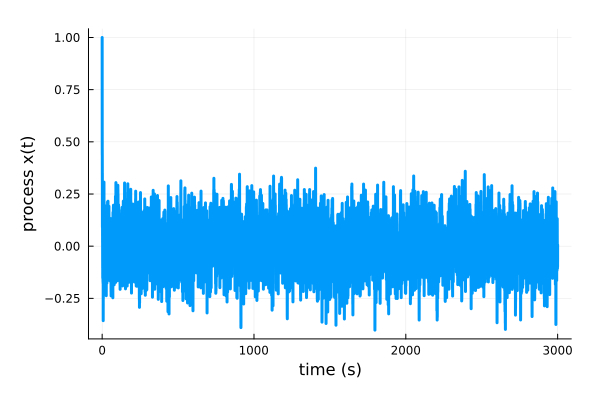

In [80]:
plot(tsteps, signal, label="", xlabel="time (s)", ylabel="process x(t)")

## Temporal Gaussian process

### Matern-1/2 GP in state-space form
Suppose a function $x(t)$ follows a zero-mean Gaussian Process

$$\begin{aligned}
x(t) \sim \mathcal{GP}(0, k(t,t')) \, .
\end{aligned}$$

The GP can be written as the following differential equation ([Hartikainen, 2013)](https://aaltodoc.aalto.fi/bitstream/handle/123456789/7579/isbn9789526049847.pdf?sequence=1&isAllowed=y)):

$$\begin{align}
\dot{x} = F x + L w \, ,
\end{align}$$

with $x$ being states, $F$ a state transition matrix and $w$ a white noise process. The Matern GP has a stationary covariance function, defined as:

$$\begin{aligned}
k(\tau) = \sigma^2 \frac{2^{1-\nu}}{\Gamma(\nu)} \left(\frac{\sqrt{2\nu}\tau}{l} \right)^\nu K_\nu\left(\frac{\sqrt{2\nu}\tau}{l} \right)
\end{aligned}$$

where $\sigma^2$ is a scale hyperparameter, $l$ a characteristic length-scale, $\nu$ the smoothness hyperparameter, and $K_\nu(.)$ is a modified Bessel function of the second kind. 

Matern-1/2 refers to $\nu=1/2$. The matrices for the state space model are computed as follows:

$$\begin{aligned}
\mathbf{F} = -\lambda,\quad \quad \mathbf{L} = 1, \quad \quad \mathbf{P}_\infty = \sigma^2  ,\quad \quad  Q_c = 2\lambda\sigma^2
\end{aligned}$$ 

where $\lambda = \frac{\sqrt{3}}{l} $.


In [81]:
# # Define temporal Gaussian process
# kernel = Mat12Iso(λ_true, σ_true)
# kmean  = MeanZero()

# gp = GP(tsteps, signal, kmean, kernel)
# optimize!(gp, domean=false, kern=true)

# ppgp_m, ppgp_s = predict_y(gp, tsteps)

# window = M+1:len_time
# MAE_GP = mean(abs.(ppgp_m[window] .- signal[window]))

In [82]:
plot(tsteps, signal, label="signal", xlabel="time (s)", ylabel="process x(t)")
plot!(tsteps, ppgp_m, ribbon=ppgp_s, label="GP predictions")

## Bayesian auto-regression



In [83]:
# Model parameters
M = 1
Dy = 1
Dx = Dy*M
len_horizon = 3

# Prior parameters
α0 = 1.1
β0 = 0.01
Λ0 = 1e-3*diagm(ones(Dx))
μ0 = zeros(Dx)

model = ARModel(μ0,Λ0,α0,β0, order=M, time_horizon=len_horizon)

μs = zeros(Dx,len_time)
Λs = zeros(Dx,Dx,len_time)
αs = zeros(len_time)
βs = zeros(len_time)

ppar_m = zeros(len_time)
ppar_s = zeros(len_time)

for (k,t) in enumerate(tsteps)

    x_k = model.buffer[:]
    _,ppar_m[k],ppar_s[k] = ARModels.posterior_predictive(model, x_k)

    # Update parameters
    ARModels.update!(model, signal[k])

    # Store
    μs[:,k]   = model.μ
    Λs[:,:,k] = model.Λ
    αs[k]     = model.α
    βs[k]     = model.β

end

In [84]:
window = M+2:len_time
MAE_AR = mean(abs.(ppar_m[window] .- signal[window]))

println("MAE GP = $MAE_GP")
println("MAE AR = $MAE_AR")

MAE GP = 2.983908210698965e-13
MAE AR = 0.034838553880753485


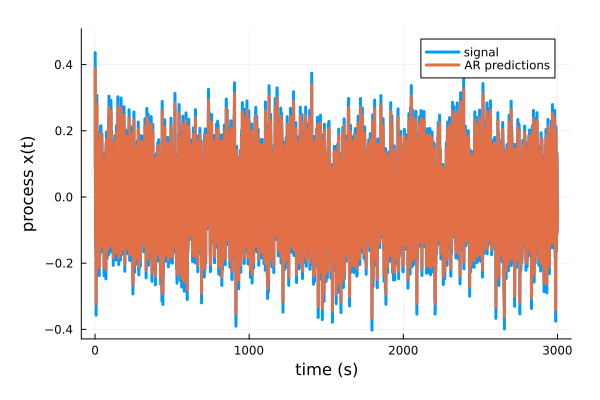

In [85]:
window = 10:len_time
plot(tsteps[window], signal[window], label="signal", xlabel="time (s)", ylabel="process x(t)")
plot!(tsteps[window], ppar_m[window], ribbon=ppar_s[window], label="AR predictions")

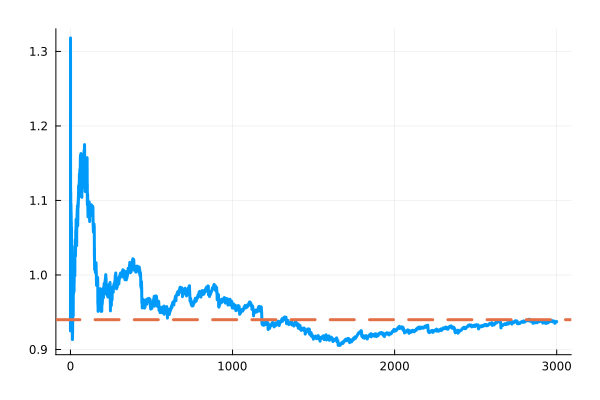

In [86]:
invert_λ(θ) = (1 .- θ)./Δt

plot(tsteps[M+1:end], invert_λ.(μs[:,M+1:end][:]))
hline!([λ_true], linestyle=:dash)

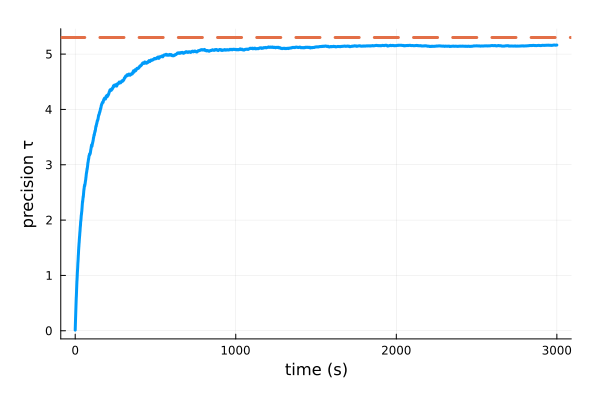

In [87]:
τ_hat = ((αs .- 1) ./ βs ) .* Δt^2

plot(xlabel="time (s)", ylabel="precision τ")
plot!(tsteps, τ_hat)
hline!([τ_true], linestyle=:dash)

In [69]:
# Kernel hyperparameter priors
α_l = 5.
β_l = 0.1
α_γ = 5.
β_γ = 0.1

prior_l = GammaShapeRate(α_l, β_l)
prior_γ = GammaShapeRate(α_γ, β_γ)

[mode(GammaShapeRate(α_l, β_l)) mean(GammaShapeRate(α_l, β_l))  var(GammaShapeRate(α_l, β_l))]

1×3 Matrix{Float64}:
 40.0  50.0  500.0

In [13]:
function J(hparams::AbstractVector)

    λ = sqrt(3)/hparams[1]
    A = [inv(M)*(K-true_h_a*diagm(An))              inv(M);
         zeros(Dh,Dh)                   -λ*diagm(ones(Dh))]*Δt + diagm(ones(Dx))
        
    Q = analyticQ(inv(M), λ, hparams[2], Δt=Δt)
        
    m0 = [τ_0; zeros(3)]
    S0 = diagm([1e-3ones(3); hparams[2]^2*ones(3)])

    results = infer(
        model       = SSM(A=A, B=B, C=C, Q=Q, R=R, m0=m0, S0=S0, T=T),
        data        = (y = output_, u = inputs_),
        options     = (limit_stack_depth = 100,),
        free_energy = true,
    )

    return results.free_energy[end] - logpdf(prior_l, hparams[1]) -logpdf(prior_γ, hparams[2])
end

J (generic function with 1 method)

In [14]:
# ops = Optim.Options(f_tol=1e-3, g_tol=1e-3, time_limit=60, show_every=1)
# res = optimize(J, 1e0, 1e6, [10., 10.], Fminbox(LBFGS()), ops; autodiff=:forward)
# l_star, γ_star = Optim.minimizer(res)

l_star = 1423.21
γ_star = 20.345

20.345